Import bibliotek:

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.preprocessing import LabelEncoder
sns.set_theme()

In [3]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


Wczytanie pliku:

In [4]:
df = pd.read_csv('star_classification.csv')
df.head(10)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
5,1.237680e+18,340.995121,20.589476,23.48827,23.33776,21.32195,20.25615,19.54544,8102,301,3,110,5.658977e+18,QSO,1.424659,5026,55855,741
6,1.237679e+18,23.234926,11.418188,21.46973,21.17624,20.92829,20.60826,20.42573,7773,301,2,462,1.246262e+19,QSO,0.586455,11069,58456,113
7,1.237679e+18,5.433176,12.065186,22.24979,22.02172,20.34126,19.48794,18.84999,7773,301,2,346,6.961443e+18,GALAXY,0.477009,6183,56210,15
8,1.237661e+18,200.290475,47.199402,24.40286,22.35669,20.61032,19.46490,18.95852,3716,301,5,108,7.459285e+18,GALAXY,0.660012,6625,56386,719
9,1.237671e+18,39.149691,28.102842,21.74669,20.03493,19.17553,18.81823,18.65422,5934,301,4,122,2.751763e+18,STAR,-0.000008,2444,54082,232


## Czyszczenie danych

Usunięcie kolumn zawierjących dane porządkowe:

In [5]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [6]:
df = df.drop(columns=['obj_ID','run_ID','rerun_ID','cam_col','field_ID','spec_obj_ID','plate','MJD','fiber_ID'])

In [7]:
df

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040


Sprawdzenie, czy występują wiersze bez wartości:

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alpha     100000 non-null  float64
 1   delta     100000 non-null  float64
 2   u         100000 non-null  float64
 3   g         100000 non-null  float64
 4   r         100000 non-null  float64
 5   i         100000 non-null  float64
 6   z         100000 non-null  float64
 7   class     100000 non-null  str    
 8   redshift  100000 non-null  float64
dtypes: float64(8), str(1)
memory usage: 6.9 MB


In [9]:
df.dropna(inplace= True)

Sprawdzenie czy są duplikaty

In [10]:
print(df.duplicated().sum())

0


Sprawdzenie ilości obiektów w bazie:

In [11]:
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='Count'>

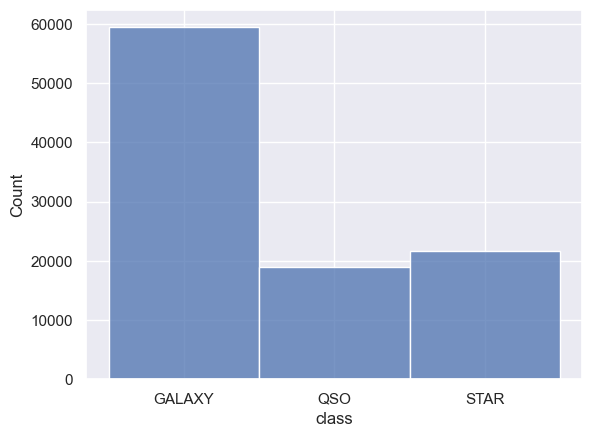

In [12]:
sns.histplot(df['class'], bins=20)

Zmniejszenie ilości typu - GALAXY:

<Axes: >

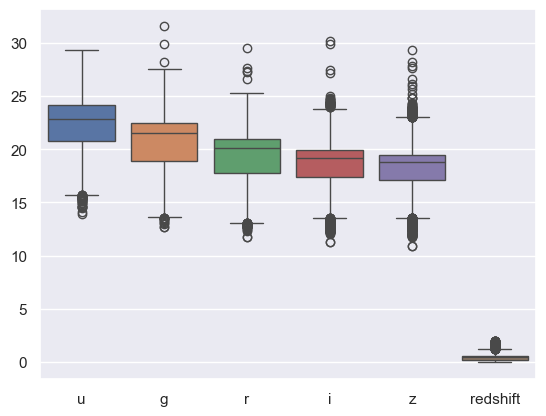

In [13]:
kolumny = [ 'u', 'g', 'r', 'i', 'z', 'redshift']
sns.boxplot(data=df[df['class'] == 'GALAXY'][kolumny])

Usunięcie kilku rekordów z najpowszechniejszymi danymi:

In [14]:
galaxies = df[df['class'] == 'GALAXY']

In [15]:
galaxies

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040


In [16]:

mean_val = galaxies[kolumny].mean()
galaxies['distance_from_mean'] = abs(galaxies[kolumny] - mean_val).sum(axis=1)
galaxies_to_keep = galaxies.sort_values('distance_from_mean').iloc[16000:]

lub losowe usuniecie

In [17]:
#galaxies_to_keep = galaxies.sample(n=45000, random_state=69)

In [18]:
galaxies_to_keep

,alpha,delta,u,g,r,i,z,class,redshift,distance_from_mean
7101,157.950923,21.472524,25.25071,21.88149,20.10294,19.16202,18.62602,GALAXY,0.504845,4.724250
36128,164.701517,28.029402,26.17231,20.78468,19.28783,18.51689,18.10081,GALAXY,0.456591,4.724515
73417,336.855075,3.398406,23.28275,22.56748,20.62978,19.47543,19.02638,GALAXY,0.546627,4.724672
31616,245.575721,57.804339,21.64708,20.14033,18.44255,17.89860,17.61302,GALAXY,0.337376,4.724819
65873,41.703954,-2.095679,23.85249,22.18595,20.44859,19.40830,19.11226,GALAXY,0.521534,4.725350
...,...,...,...,...,...,...,...,...,...,...
14829,227.304839,52.528432,14.65722,13.16663,12.39703,12.02013,11.79859,GALAXY,0.011695,36.752480
75369,190.469664,41.273959,14.14713,13.03562,12.46865,12.20838,12.04390,GALAXY,0.002028,36.898067
31397,148.825254,4.270018,13.89799,12.95238,12.33823,12.12910,11.84838,GALAXY,0.006010,37.631685
81298,8.511630,-9.705282,14.56010,12.68849,11.77229,11.31937,10.89738,GALAXY,0.012450,39.553694


Wymiana na nowy zbiór galaktyk:

In [19]:
do_usuniecia = df[df['class'] == 'GALAXY'].index
df = df.drop(do_usuniecia)

In [20]:
df2 = pd.concat([galaxies_to_keep, df])

In [21]:
df2 = df2.drop('distance_from_mean', axis=1)

<Axes: >

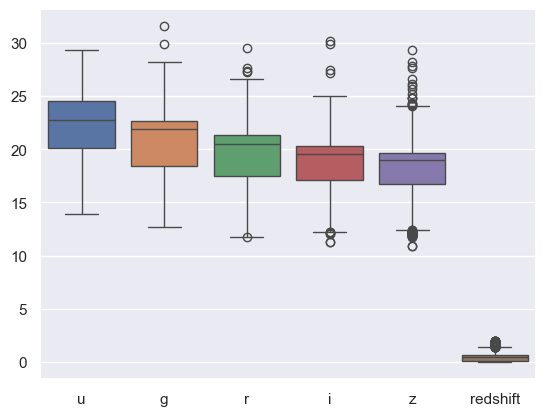

In [22]:
sns.boxplot(data=df2[df2['class'] == 'GALAXY'][kolumny])

<Axes: xlabel='class', ylabel='Count'>

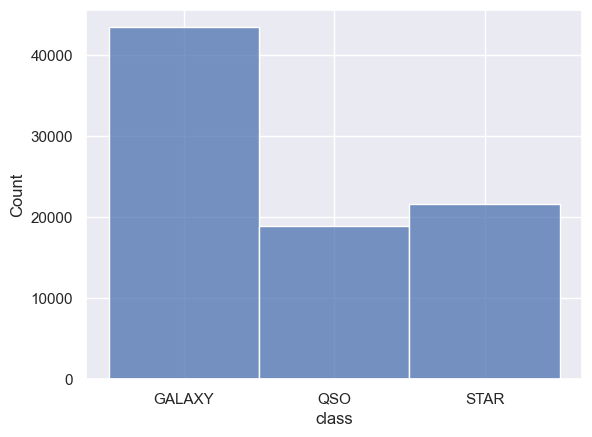

In [23]:
sns.histplot(df2['class'], bins=20)

Sprawdzenie poprawności rekordów typu STAR

<Axes: >

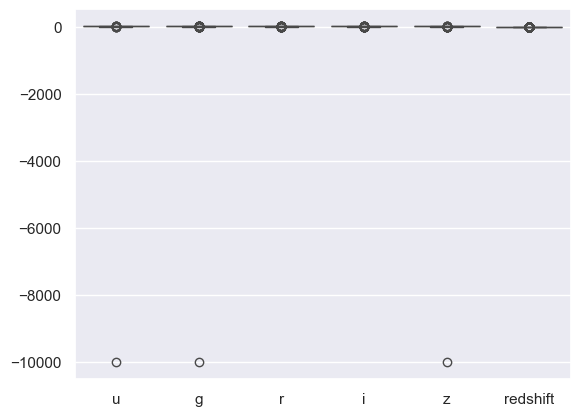

In [24]:
sns.boxplot(data=df2[df2['class'] == 'STAR'][kolumny])

"Ukryte" braki danych

In [25]:
df2.replace(-9999, np.nan, inplace=True)
df2.dropna(inplace=True)


<Axes: >

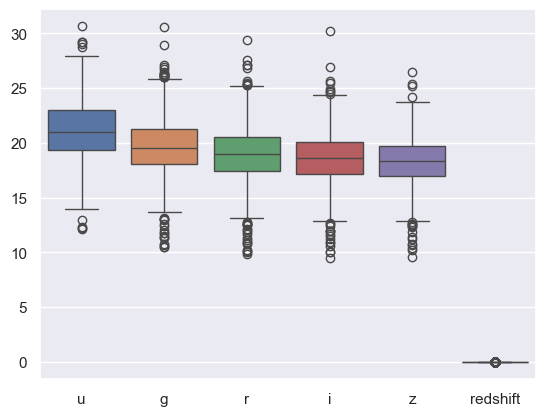

In [26]:
sns.boxplot(data=df2[df2['class'] == 'STAR'][kolumny])

Sprawdzenie wartości obiektów QSO

<Axes: >

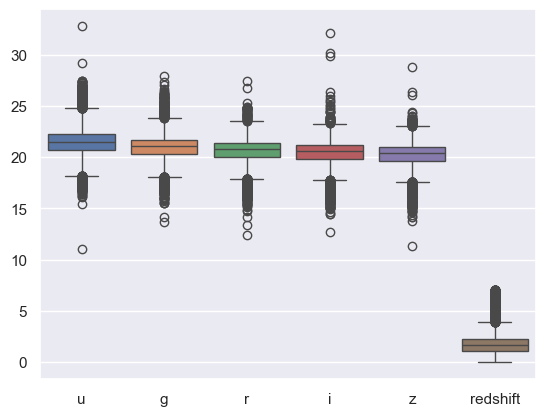

In [27]:
sns.boxplot(data=df2[df2['class'] == 'QSO'][kolumny])

One-Hot-Encoding

In [28]:
#df_encoded = pd.get_dummies(df2, columns=['class'])

lub label encoding

In [29]:
le = LabelEncoder()
df_encoded = df2
df_encoded['target'] = le.fit_transform(df2['class']) 
df_encoded =df_encoded.drop('class',axis = 1)

In [30]:
df_encoded.tail(8)

,alpha,delta,u,g,r,i,z,redshift,target
99953,178.261225,1.174416,21.18402,20.72292,20.75580,20.48850,20.46614,0.576586,1
99955,172.281648,-8.909060,22.26657,20.76710,20.22759,20.08172,19.98396,-0.000395,2
99959,169.371328,12.285850,22.28911,21.02551,20.72092,20.54853,20.10718,0.000367,2
99961,134.347759,47.771911,24.17897,22.89025,21.26451,20.94941,19.87500,0.219966,1
99966,222.761686,32.203212,20.23421,19.76480,19.46940,19.36135,19.21768,0.398574,1
99968,259.504325,31.462416,24.86685,23.22772,21.82982,21.80359,21.56733,1.239638,1
99977,217.958430,52.316738,24.15617,22.05986,21.80826,21.95129,21.24179,1.067543,1
99980,225.566376,32.118746,20.53765,19.93229,19.77495,19.72304,19.40202,2.488738,1


Ostateczne sprawdzenie, czy zbiór jest gotowy:

In [31]:
df_encoded.isnull().sum()

alpha       0
delta       0
u           0
g           0
r           0
i           0
z           0
redshift    0
target      0
dtype: int64

In [32]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 83999 entries, 7101 to 99980
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   alpha     83999 non-null  float64
 1   delta     83999 non-null  float64
 2   u         83999 non-null  float64
 3   g         83999 non-null  float64
 4   r         83999 non-null  float64
 5   i         83999 non-null  float64
 6   z         83999 non-null  float64
 7   redshift  83999 non-null  float64
 8   target    83999 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 6.4 MB


Sprawdzenie, czy kolumny nie mają za dużej korelacji:

<Axes: >

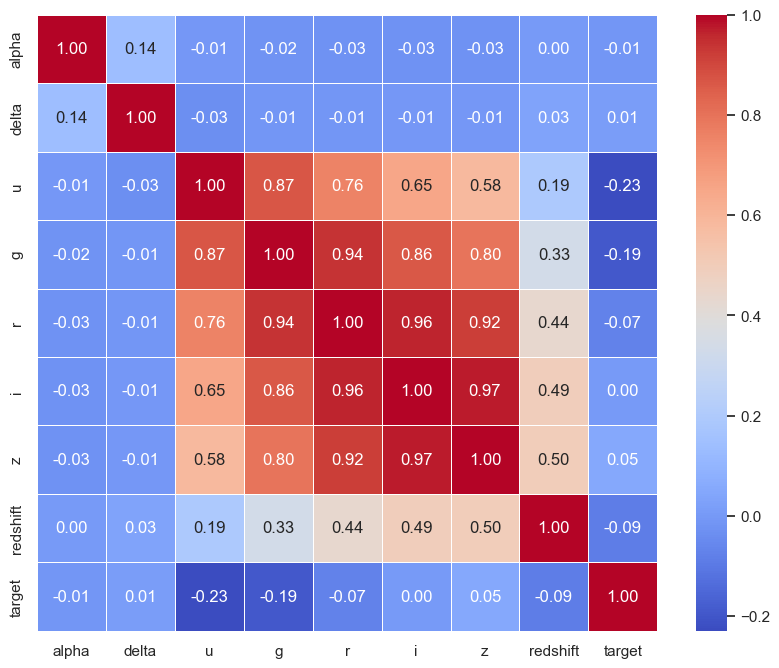

In [33]:
corr = df_encoded.corr()
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [34]:
df_encoded.describe()

,alpha,delta,u,g,r,i,z,redshift,target
count,83999.000000,83999.000000,83999.000000,83999.000000,83999.000000,83999.000000,83999.000000,83999.000000,83999.000000
mean,177.210272,24.194355,21.889885,20.499028,19.627516,19.109794,18.813589,0.602340,0.739854
std,96.761225,19.608529,2.364829,2.180225,2.004935,1.903619,1.910149,0.792751,0.840597
min,0.010959,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971,0.000000
25%,126.602375,5.086699,20.040445,18.602790,17.754180,17.362335,17.102755,0.000494,0.000000
50%,180.224092,24.027839,21.778190,20.878230,20.305920,19.635430,19.232400,0.337938,0.000000
75%,234.390009,40.003626,23.694890,22.256555,21.221615,20.597805,20.169940,0.795529,2.000000
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245,2.000000


## Budowa modelu

In [35]:
X = df_encoded[['u','g','r','i','z','redshift','alpha','delta']]
Y = df_encoded[['target']]

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

## Stworzenie i trenowanie modelu

In [37]:
model = xgb.XGBClassifier(
    n_estimators=100,      # ile drzewek zbudować
    max_depth=3,           # jak głębokie mogą być drzewka
    learning_rate=0.1,     # jak szybko się uczy 
    random_state=42
)

In [38]:
model.fit(X_train, Y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

## Ocena modelu

In [39]:
Y_pred = model.predict(X_test)

In [40]:
print("Train accuracy:", accuracy_score(Y_train, model.predict(X_train)))

Train accuracy: 0.9714281462521763


In [41]:
print("Test accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Test accuracy: 0.9697023809523809
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      8708
           1       0.95      0.93      0.94      3779
           2       0.99      1.00      0.99      4313

    accuracy                           0.97     16800
   macro avg       0.97      0.97      0.97     16800
weighted avg       0.97      0.97      0.97     16800



## Ważność cech

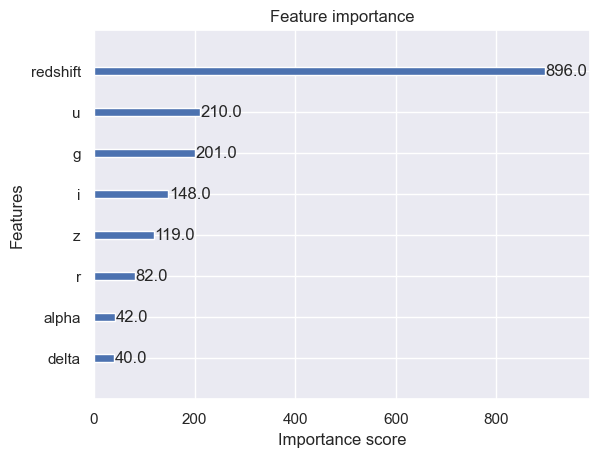

In [42]:

xgb.plot_importance(model)

plt.show()